In [3]:
# Importing libraries for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing the Iris dataset
from sklearn.datasets import load_iris

# Importing tools for splitting and preprocessing data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Importing machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# Importing evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [4]:
# Load the built-in Iris dataset
iris = load_iris()

# Create a DataFrame containing the four flower measurements
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target species to the DataFrame
df["species"] = [
    iris.target_names[target]
    for target in iris.target
]

# Display the first five rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [5]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display the data types of each column
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (150, 5)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


In [6]:
# Check the number of missing values in every column
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [7]:
# Generate statistical information for numerical features
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Text(0.5, 1.02, 'Pairwise Relationships of Iris Features')

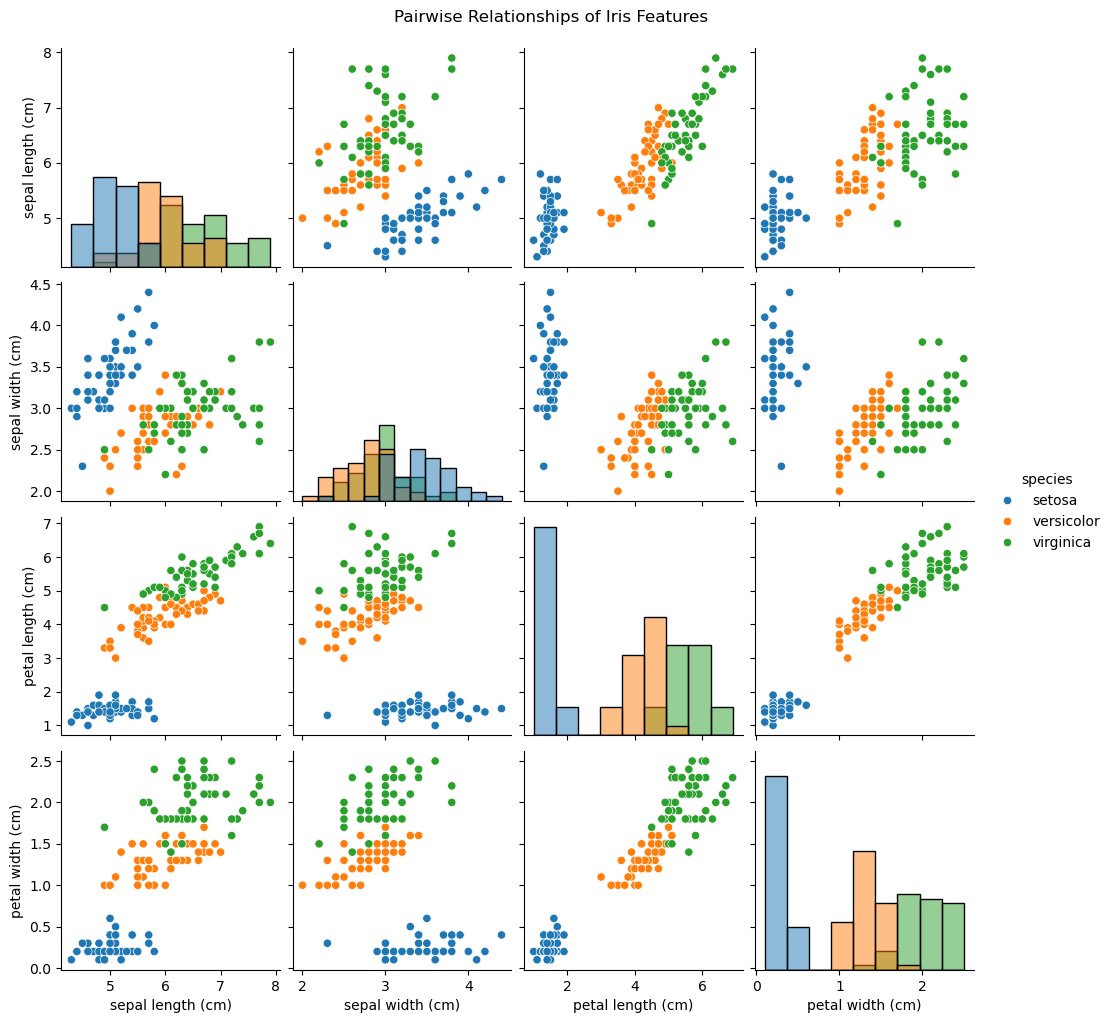

In [8]:
# Visualize relationships between all numerical features
# Different colors represent different flower species
sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Pairwise Relationships of Iris Features",
    y=1.02
)

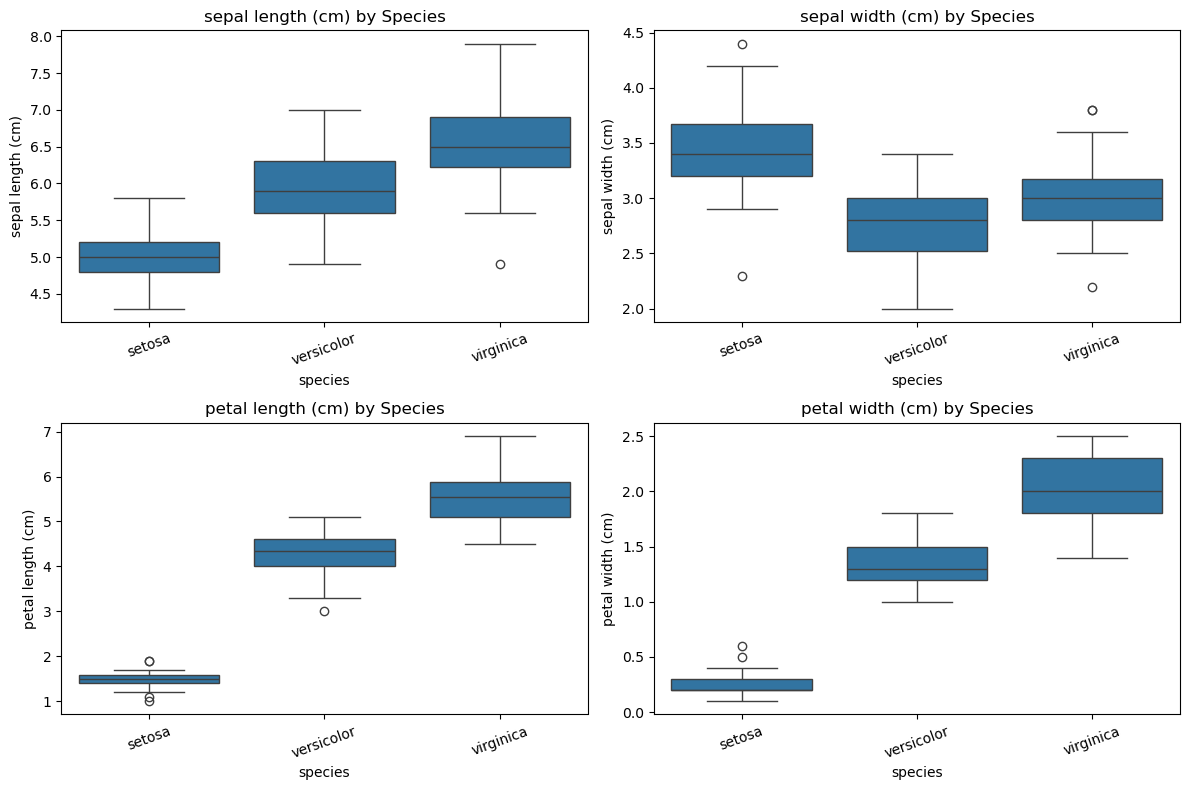

In [10]:
# Create box plots for all four numerical features
features = iris.feature_names

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)

    sns.boxplot(
        data=df,
        x="species",
        y=feature
    )

    plt.title(f"{feature} by Species")
    plt.xticks(rotation=20)

plt.tight_layout()

Text(0.5, 1.0, 'Feature Correlation Matrix')

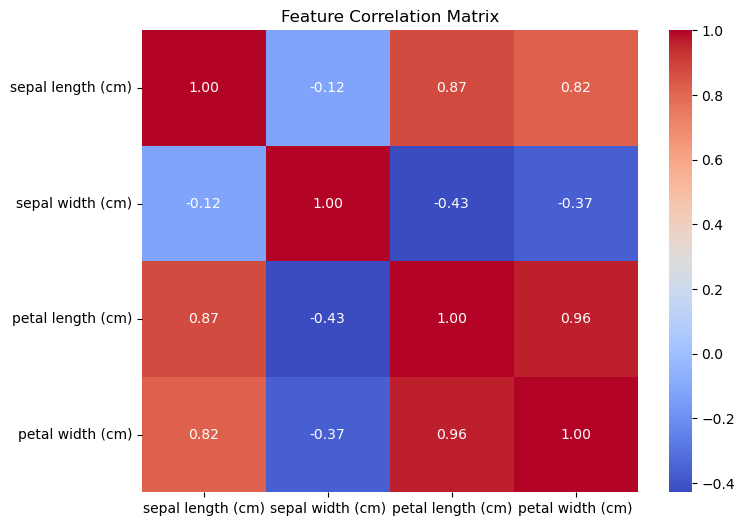

In [12]:
# Calculate correlations between numerical variables
correlation_matrix = df[features].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Matrix")

In [13]:
# X contains the input features
X = df[features]

# y contains the target labels
y = iris.target

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (150, 4)
Target shape: (150,)


In [14]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [15]:
# Create a pipeline that first standardizes the features
# and then trains a Logistic Regression classifier
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=200))
])

# Train the model
logistic_model.fit(X_train, y_train)

# Generate predictions
logistic_predictions = logistic_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print("Logistic Regression Accuracy:",
      round(logistic_accuracy, 4))

Logistic Regression Accuracy: 0.9333


In [16]:
# Create a KNN pipeline with feature scaling
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

# Train the KNN model
knn_model.fit(X_train, y_train)

# Generate predictions
knn_predictions = knn_model.predict(X_test)

# Calculate accuracy
knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

print("KNN Accuracy:",
      round(knn_accuracy, 4))

KNN Accuracy: 0.9333


In [17]:
print("Logistic Regression Classification Report\n")

print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=iris.target_names
    )
)

Logistic Regression Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Text(0.5, 1.0, 'Logistic Regression - Confusion Matrix')

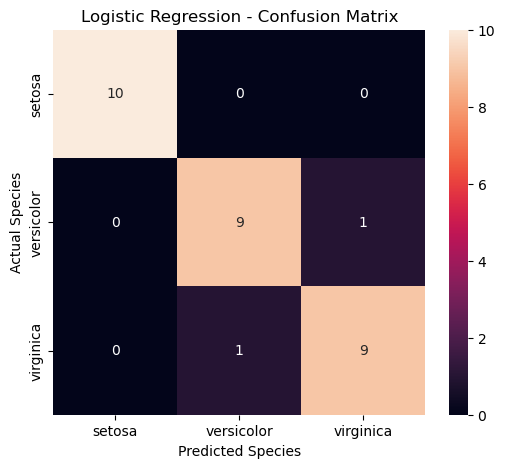

In [19]:
# Generate confusion matrix
cm_logistic = confusion_matrix(
    y_test,
    logistic_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("Logistic Regression - Confusion Matrix")

In [20]:
print("KNN Classification Report\n")

print(
    classification_report(
        y_test,
        knn_predictions,
        target_names=iris.target_names
    )
)

KNN Classification Report

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



Text(0.5, 1.0, 'KNN - Confusion Matrix')

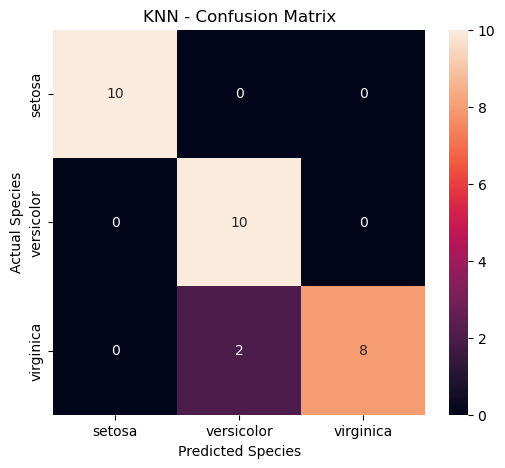

In [22]:
# Generate confusion matrix
cm_knn = confusion_matrix(
    y_test,
    knn_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")
plt.title("KNN - Confusion Matrix")

In [23]:
# Store model performance in a DataFrame
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "K-Nearest Neighbours"
    ],
    "Accuracy": [
        logistic_accuracy,
        knn_accuracy
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.933333
1,K-Nearest Neighbours,0.933333


In [24]:
# Display the best-performing model
best_model = model_results.loc[
    model_results["Accuracy"].idxmax()
]

print(
    "Best Performing Model:",
    best_model["Model"]
)

print(
    "Accuracy:",
    round(best_model["Accuracy"], 4)
)

Best Performing Model: Logistic Regression
Accuracy: 0.9333
